<a href="https://colab.research.google.com/github/theerthavijayachandrands25-dot/Predictive-Analytics-Lab-Exam-2./blob/main/predictice_lab_exam_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
url="/content/Lab_Exam_binary_classification_dataset.csv"
df=pd.read_csv(url)
df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [6]:
df.describe()

,Feature1,Feature2
count,1020.000000,1020.000000
mean,11.436679,520.988235
std,313.061049,69.793442
min,1.250000,400.000000
25%,1.450000,464.000000
50%,1.637500,520.000000
75%,1.828125,584.000000
max,10000.000000,640.000000


In [7]:
df.shape

(1020, 3)

In [8]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Target,20


In [9]:
df.duplicated().sum()

np.int64(102)

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Target,0


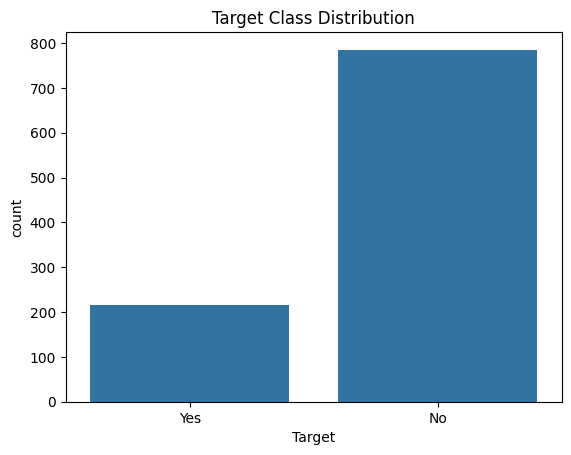

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Target', data=df)
plt.title("Target Class Distribution")
plt.show()

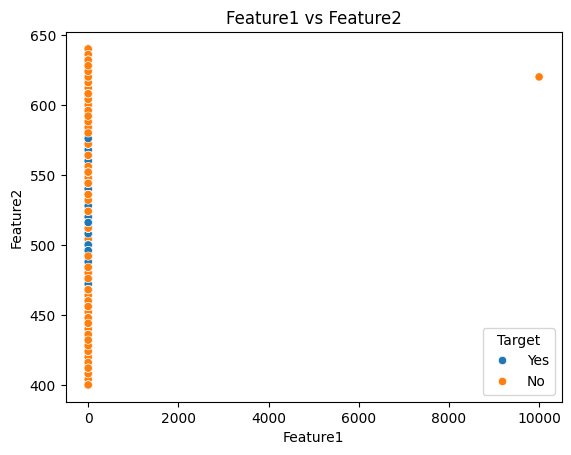

In [14]:
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=df)
plt.title("Feature1 vs Feature2")
plt.show()

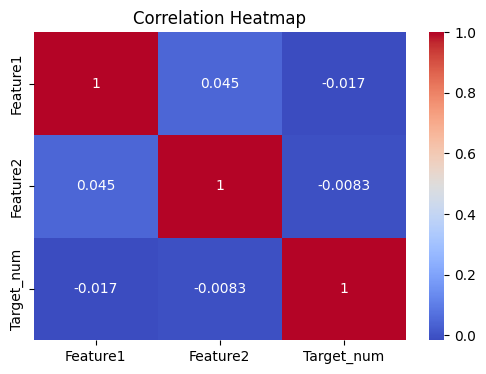

In [17]:
df['Target_num'] = df['Target'].map({'No':0, 'Yes':1})
df_numeric = df.drop('Target', axis=1)
corr = df_numeric.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

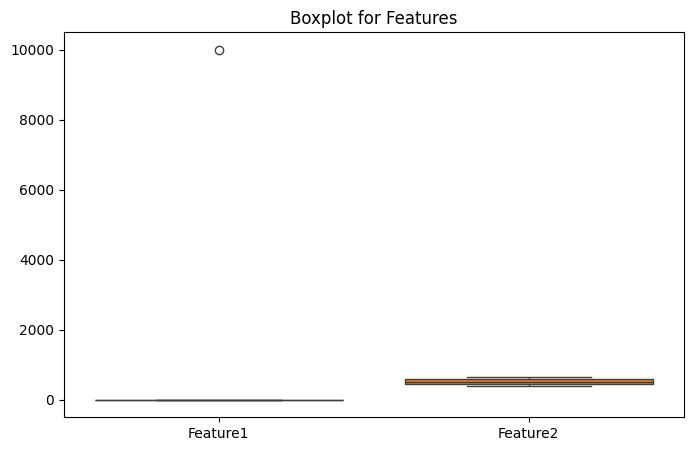

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Feature1', 'Feature2']])
plt.title("Boxplot for Features")
plt.show()

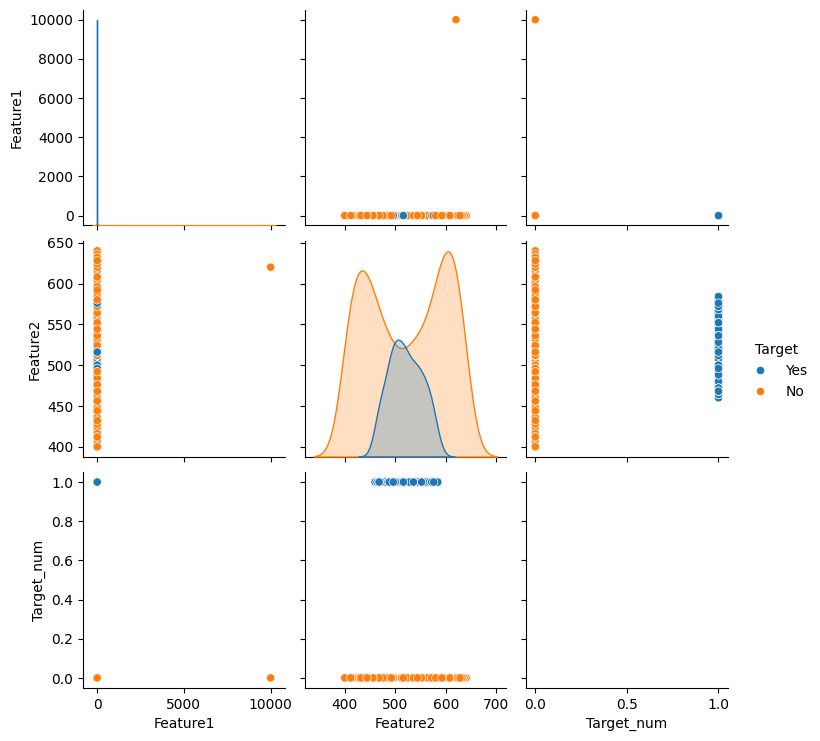

In [19]:
sns.pairplot(df, hue='Target')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [22]:
df['Target'] = df['Target'].map({'No': 0, 'Yes': 1})
X = df[['Feature1', 'Feature2']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


Accuracy: 0.935

Confusion Matrix:
 [[147   6]
 [  7  40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       153
           1       0.87      0.85      0.86        47

    accuracy                           0.94       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.93      0.94      0.93       200



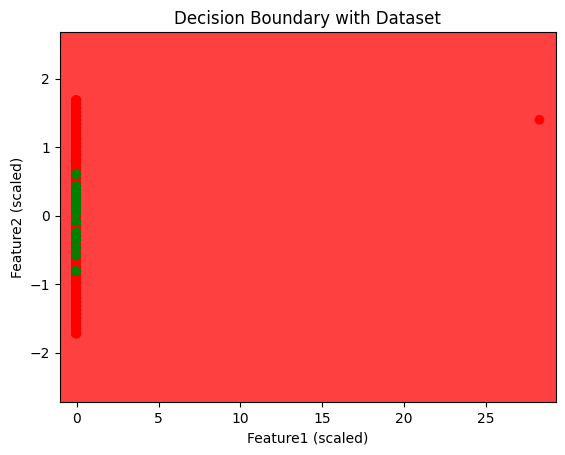

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

# Use training data
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Create mesh grid
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

# Predict over grid
Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

# Plot decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))

# Plot actual data points
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))

# Labels and title
plt.title("Decision Boundary with Dataset")
plt.xlabel("Feature1 (scaled)")
plt.ylabel("Feature2 (scaled)")

plt.show()